# Phase 1: Exploratory Data Analysis
## Task 1.1 — Parse metadata into DataFrames

**Mục tiêu:** Tạo 2 DataFrame sạch từ training_data.csv:
- `patients.csv` — 1 row per patient (demographics + labels)
- `recordings.csv` — 1 row per .wav file (location, duration, path)

In [1]:
import sys
sys.path.insert(0, "..")  # project root, vì notebook nằm trong notebooks/

import pandas as pd
import numpy as np

from src.data.parse_metadata import load_patient_df, load_recording_df, save_metadata

In [6]:
# Parse và save — recording_df mất vài phút vì đọc 3163 file .wav
patient_df, recording_df = save_metadata(
    data_dir="../data/raw/training_data",
    output_dir="../data/metadata"
)

Saved patients.csv: (942, 24)
Saved recordings.csv: (3163, 6)


In [4]:
print("=== Patient DataFrame ===")
print(f"Shape: {patient_df.shape}")
print(patient_df.head())
print(f"\nMurmur distribution:\n{patient_df['murmur'].value_counts()}")
print(f"\nAge distribution:\n{patient_df['age'].value_counts()}")

print("\n=== Recording DataFrame ===")
print(f"Shape: {recording_df.shape}")
print(recording_df.head())
print(f"\nDuration stats:\n{recording_df['duration_seconds'].describe()}")

=== Patient DataFrame ===
Shape: (942, 24)
   patient_id recording_locations    age     sex  height  weight  \
0        2530         AV+PV+TV+MV  Child  Female    98.0    15.9   
1        9979         AV+PV+TV+MV  Child  Female   103.0    13.1   
2        9983         AV+PV+TV+MV  Child    Male   115.0    19.1   
3       13918         AV+PV+TV+MV  Child    Male    98.0    15.9   
4       14241         AV+PV+TV+MV  Child    Male    87.0    11.2   

  pregnancy_status   murmur murmur_locations most_audible_location  ...  \
0              NaN   Absent              NaN                   NaN  ...   
1              NaN  Present      AV+MV+PV+TV                    TV  ...   
2              NaN  Unknown              NaN                   NaN  ...   
3              NaN  Present               TV                    TV  ...   
4              NaN  Present      AV+MV+PV+TV                    PV  ...   

  systolic_murmur_quality diastolic_murmur_timing  diastolic_murmur_shape  \
0                   

In [7]:
# Xem pandas đọc pregnancy_status thành kiểu gì
raw = pd.read_csv("../data/raw/training_data.csv")
print("Type of first value:", type(raw["Pregnancy status"].iloc[0]))
print("Unique values:", raw["Pregnancy status"].unique())
print("Value counts:\n", raw["Pregnancy status"].value_counts(dropna=False))


Type of first value: <class 'numpy.bool'>
Unique values: [False  True]
Value counts:
 Pregnancy status
False    872
True      70
Name: count, dtype: int64


In [8]:
# Recordings nào thiếu duration?
missing = recording_df[recording_df["duration_seconds"].isna()]
print(f"Missing durations: {len(missing)}")
print(missing.head(10))

Missing durations: 43
     patient_id location                                wav_path  \
211       49748       AV  ../data/raw/training_data\49748_AV.wav   
212       49748       AV  ../data/raw/training_data\49748_AV.wav   
213       49748       PV  ../data/raw/training_data\49748_PV.wav   
214       49748       PV  ../data/raw/training_data\49748_PV.wav   
296       49952       MV  ../data/raw/training_data\49952_MV.wav   
297       49952       MV  ../data/raw/training_data\49952_MV.wav   
412       50032       TV  ../data/raw/training_data\50032_TV.wav   
413       50032       TV  ../data/raw/training_data\50032_TV.wav   
533       50115       PV  ../data/raw/training_data\50115_PV.wav   
534       50115       PV  ../data/raw/training_data\50115_PV.wav   

                                   tsv_path  duration_seconds   murmur  
211  ../data/raw/training_data\49748_AV.tsv               NaN  Present  
212  ../data/raw/training_data\49748_AV.tsv               NaN  Present  
213  ../da

In [9]:
# Bug 1: Tại sao có duplicate rows? Kiểm tra patient 49748
print("Patient 49748 recording_locations:", 
      patient_df[patient_df["patient_id"] == 49748]["recording_locations"].values)

# Đếm duplicates trong recording_df
dupes = recording_df[recording_df.duplicated(subset=["patient_id", "location"], keep=False)]
print(f"\nDuplicate patient+location pairs: {len(dupes)}")
print(dupes.head(10))

# Kiểm tra file thực sự có tồn tại không
import os
test_path = "../data/raw/training_data/49748_AV.wav"
print(f"\nFile exists? {os.path.exists(test_path)}")

Patient 49748 recording_locations: ['AV+AV+PV+PV+TV+MV']

Duplicate patient+location pairs: 43
     patient_id location                                wav_path  \
211       49748       AV  ../data/raw/training_data\49748_AV.wav   
212       49748       AV  ../data/raw/training_data\49748_AV.wav   
213       49748       PV  ../data/raw/training_data\49748_PV.wav   
214       49748       PV  ../data/raw/training_data\49748_PV.wav   
296       49952       MV  ../data/raw/training_data\49952_MV.wav   
297       49952       MV  ../data/raw/training_data\49952_MV.wav   
412       50032       TV  ../data/raw/training_data\50032_TV.wav   
413       50032       TV  ../data/raw/training_data\50032_TV.wav   
533       50115       PV  ../data/raw/training_data\50115_PV.wav   
534       50115       PV  ../data/raw/training_data\50115_PV.wav   

                                   tsv_path  duration_seconds   murmur  
211  ../data/raw/training_data\49748_AV.tsv               NaN  Present  
212  ../da

In [11]:
# Reload module sau khi sửa parse_metadata.py
import importlib
import src.data.parse_metadata as pm
importlib.reload(pm)

# Chạy lại với code đã fix
patient_df, recording_df = pm.save_metadata(
    data_dir="../data/raw/training_data",
    output_dir="../data/metadata"
)

Loading patient metadata...
  Saved patients.csv: (942, 24)
Building recording metadata (reading .wav durations)...
  Processed 200/942 patients...
  Processed 400/942 patients...
  Processed 600/942 patients...
  Processed 800/942 patients...
  Saved recordings.csv: (3163, 6)


In [ ]:
# Verify fixes
print("=== Pregnancy status ===")
print(patient_df["pregnancy_status"].value_counts(dropna=False))

print("\n=== Recording DF ===")
print(f"Shape: {recording_df.shape}")
print(f"Missing durations: {recording_df['duration_seconds'].isna().sum()}")

print("\n=== Patient 49748 (had duplicate locations) ===")
print(recording_df[recording_df["patient_id"] == 49748][
    ["patient_id", "location", "wav_path", "duration_seconds"]
])

## Task 1.2 — Dataset-level statistics

In [15]:
# === Dataset overview ===
summary = {
    "Total patients": len(patient_df),
    "Total recordings": len(recording_df),
    "Recordings per patient (mean)": patient_df["num_recordings"].mean(),
    "Recordings per patient (median)": patient_df["num_recordings"].median(),
    "Unique auscultation locations": recording_df["location"].nunique(),
    "Duration — mean (s)": recording_df["duration_seconds"].mean(),
    "Duration — median (s)": recording_df["duration_seconds"].median(),
    "Duration — min (s)": recording_df["duration_seconds"].min(),
    "Duration — max (s)": recording_df["duration_seconds"].max(),
    "Duration — std (s)": recording_df["duration_seconds"].std(),
    "Campaigns": patient_df["campaign"].nunique(),
}

summary_df = pd.DataFrame(
    summary.items(), columns=["Metric", "Value"]
)
summary_df["Value"] = summary_df["Value"].apply(
    lambda x: f"{x:.2f}" if isinstance(x, float) else str(x)
)
print(summary_df.to_string(index=False))

                         Metric   Value
                 Total patients  942.00
               Total recordings 3163.00
  Recordings per patient (mean)    3.36
Recordings per patient (median)    4.00
  Unique auscultation locations    5.00
            Duration — mean (s)   22.87
          Duration — median (s)   21.46
             Duration — min (s)    5.15
             Duration — max (s)   64.51
             Duration — std (s)    7.28
                      Campaigns    2.00


In [16]:
# === Missing data ===
missing_cols = ["age", "height", "weight"]
missing_data = {
    col: [patient_df[col].isna().sum(), 
          f"{patient_df[col].isna().mean()*100:.1f}%"]
    for col in missing_cols
}
missing_df = pd.DataFrame(
    missing_data, index=["Missing count", "Missing %"]
).T
print("Missing data:\n", missing_df)

# === Campaign breakdown ===
print("\nCampaign breakdown:")
print(patient_df["campaign"].value_counts().to_string())

Missing data:
        Missing count Missing %
age               74      7.9%
height           116     12.3%
weight           105     11.1%

Campaign breakdown:
campaign
CC2015    557
CC2014    385


In [17]:
print("Unique locations:", recording_df["location"].unique())
print(recording_df["location"].value_counts().to_string())

Unique locations: ['AV' 'PV' 'TV' 'MV' 'Phc']
location
MV     861
AV     800
PV     766
TV     732
Phc      4


**Task 1.2 — Interpretation:**

**Dataset scale:** 942 patients with 3163 recordings across 5 auscultation locations 
(AV, PV, TV, MV, and Phc — a catch-all for non-standard positions). 
Median 4 recordings per patient cho thấy đa số patients được ghi đủ 4 vị trí chuẩn; 
mean 3.36 thấp hơn median nghĩa là một bộ phận patients chỉ có 1–2 recordings 
— cần kiểm tra thêm ở Task 1.5.

**Recording duration:** Trung bình ~23s (median ~21s), đủ dài cho 15–25 cardiac cycles 
(nhịp tim trẻ em ~80–120 bpm). Recording ngắn nhất 5.15s vẫn chứa ít nhất 
~5 cardiac cycles — vừa đủ để model phân tích. Recording dài nhất 64.5s là outlier 
nhưng không gây vấn đề.

**Missing data:** Age missing 7.9%, Height 12.3%, Weight 11.1%. Mức ~10% là chấp nhận 
được cho clinical data — không cần imputation ở giai đoạn này vì demographics 
không phải input chính của murmur detection pipeline (pipeline dùng PCG audio). 
Tuy nhiên cần exclude missing values khi vẽ demographic plots ở Task 1.4.

**Campaigns:** Dữ liệu thu từ 2 đợt (CC2014: 385, CC2015: 557). Sự khác biệt 
giữa campaigns có thể ảnh hưởng data distribution — đáng kiểm tra nếu 
murmur prevalence khác nhau giữa 2 đợt.

## Task 1.3 — Murmur class distribution (V1)

In [20]:
import importlib
import src.visualisation.style as style
importlib.reload(style)

from src.visualisation.style import (
    MURMUR_COLORS, MURMUR_ORDER, setup_style
)
import matplotlib.pyplot as plt
import os

setup_style()
os.makedirs("../figures/eda", exist_ok=True)

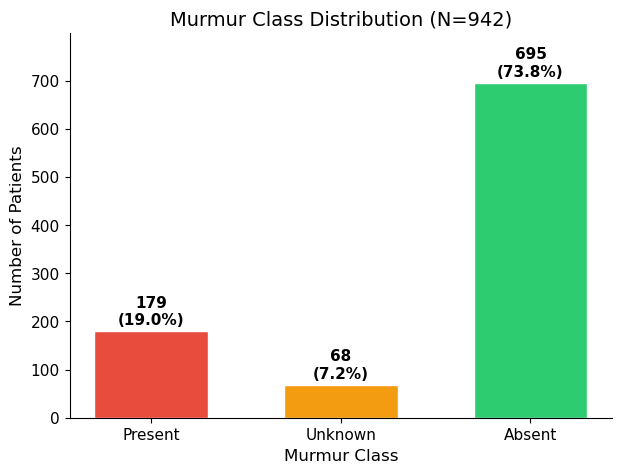

In [19]:
# Count murmur classes in fixed order
counts = patient_df["murmur"].value_counts().reindex(MURMUR_ORDER)
total = counts.sum()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    counts.index,
    counts.values,
    color=[MURMUR_COLORS[c] for c in counts.index],
    edgecolor="white",
    width=0.6,
)

# Annotate each bar: count + percentage
for bar, count in zip(bars, counts.values):
    pct = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        f"{count}\n({pct:.1f}%)",
        ha="center", va="bottom", fontweight="bold",
    )

ax.set_xlabel("Murmur Class")
ax.set_ylabel("Number of Patients")
ax.set_title("Murmur Class Distribution (N=942)")
ax.set_ylim(0, counts.max() * 1.15)

fig.savefig("../figures/eda/v1_murmur_class_distribution.png")
plt.show()

**Task 1.3 — Interpretation:**

Dataset có class imbalance rõ rệt: Absent chiếm 73.8% (695), Present chỉ 19.0% (179), 
và Unknown là minority class với 7.2% (68). Tỷ lệ ~4:1 giữa Absent và Present giải thích 
tại sao challenge dùng **weighted accuracy** (weights: Present=5, Unknown=3, Absent=1) 
thay vì accuracy thông thường — nếu model đoán tất cả là Absent, accuracy đạt 73.8% 
nhưng weighted accuracy sẽ rất thấp vì bỏ sót toàn bộ murmurs.

Unknown class (68 patients) đặc biệt khó — đây là những recordings mà ngay cả 
expert annotator cũng không thể xác định. Trong pipeline, model gán Unknown khi 
confidence C_ω̂ < 0.65, nghĩa là Unknown phản ánh signal quality hơn là 
một clinical category riêng biệt.

## Task 1.4 — Demographic distributions (V2)
Đang làm gì: Khám phá mối quan hệ giữa demographics (age, sex, height, weight) và murmur status.
Mục tiêu: Tìm patterns — murmur có tập trung ở nhóm tuổi/giới tính nào không? Dataset có bị skew không?
Kết quả mong đợi: 4 plots (age, sex, height, weight), lưu ra figures/eda/v2_*.png.

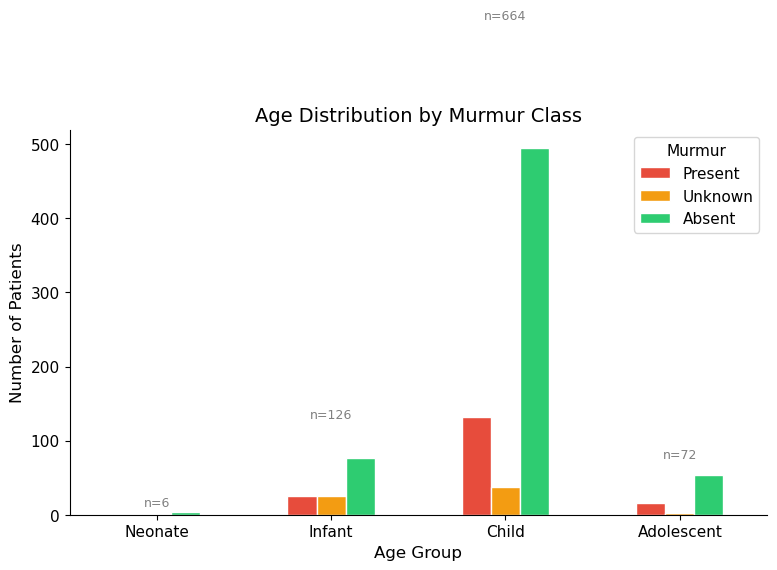

Murmur prevalence (%) by age group:
murmur      Present  Unknown  Absent
age                                 
Neonate        16.7     16.7    66.7
Infant         19.8     19.8    60.3
Child          19.9      5.6    74.5
Adolescent     22.2      4.2    73.6


In [22]:
# Age is categorical → grouped bar chart
age_murmur = (
    patient_df.groupby(["age", "murmur"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=MURMUR_ORDER)
)

fig, ax = plt.subplots(figsize=(9, 5))
age_murmur.plot(
    kind="bar",
    color=[MURMUR_COLORS[c] for c in MURMUR_ORDER],
    edgecolor="white",
    ax=ax,
)
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Patients")
ax.set_title("Age Distribution by Murmur Class")
ax.legend(title="Murmur")
ax.tick_params(axis="x", rotation=0)

# Annotate total per age group on top
for i, age_group in enumerate(age_murmur.index):
    total = age_murmur.loc[age_group].sum()
    ax.text(i, total + 5, f"n={total}", ha="center", fontsize=9, color="gray")

fig.savefig("../figures/eda/v2a_age_by_murmur.png")
plt.show()

# Also show murmur prevalence rate per age group
print("Murmur prevalence (%) by age group:")
prevalence = age_murmur.div(age_murmur.sum(axis=1), axis=0) * 100
print(prevalence.round(1).to_string())

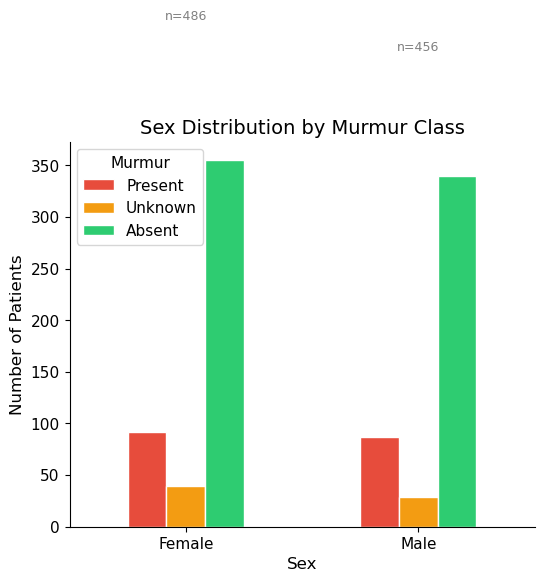

Murmur prevalence (%) by sex:
murmur  Present  Unknown  Absent
sex                             
Female     18.9      8.0    73.0
Male       19.1      6.4    74.6


In [23]:
sex_murmur = (
    patient_df.groupby(["sex", "murmur"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=MURMUR_ORDER)
)

fig, ax = plt.subplots(figsize=(6, 5))
sex_murmur.plot(
    kind="bar",
    color=[MURMUR_COLORS[c] for c in MURMUR_ORDER],
    edgecolor="white",
    ax=ax,
)
ax.set_xlabel("Sex")
ax.set_ylabel("Number of Patients")
ax.set_title("Sex Distribution by Murmur Class")
ax.legend(title="Murmur")
ax.tick_params(axis="x", rotation=0)

for i, sex in enumerate(sex_murmur.index):
    total = sex_murmur.loc[sex].sum()
    ax.text(i, total + 5, f"n={total}", ha="center", fontsize=9, color="gray")

fig.savefig("../figures/eda/v2b_sex_by_murmur.png")
plt.show()

print("Murmur prevalence (%) by sex:")
prevalence = sex_murmur.div(sex_murmur.sum(axis=1), axis=0) * 100
print(prevalence.round(1).to_string())

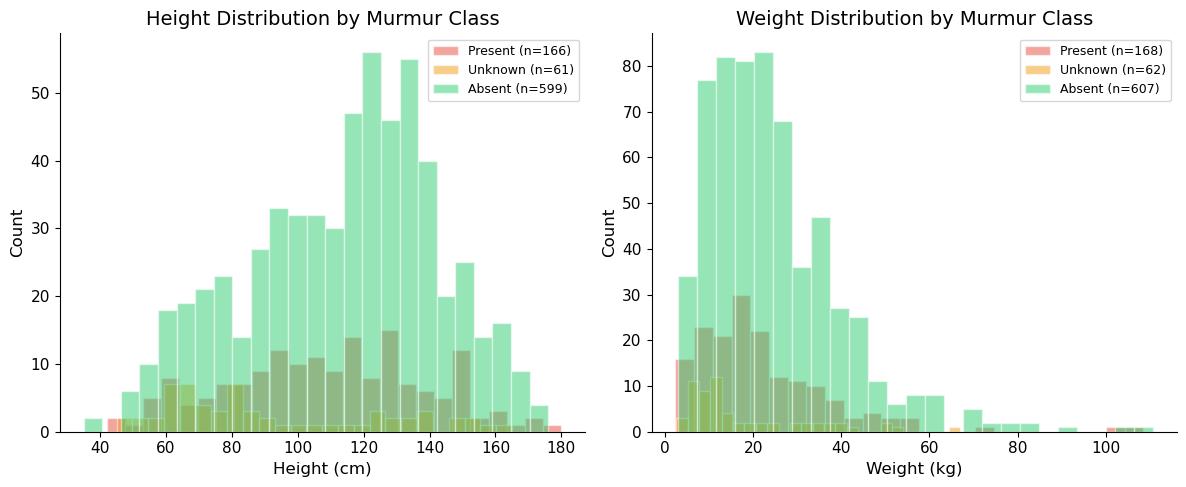

Height missing: 116 / 942
Weight missing: 105 / 942


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label in zip(axes, ["height", "weight"], ["Height (cm)", "Weight (kg)"]):
    for cls in MURMUR_ORDER:
        data = patient_df[patient_df["murmur"] == cls][col].dropna()
        ax.hist(
            data, bins=25, alpha=0.5, label=f"{cls} (n={len(data)})",
            color=MURMUR_COLORS[cls], edgecolor="white",
        )
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

axes[0].set_title("Height Distribution by Murmur Class")
axes[1].set_title("Weight Distribution by Murmur Class")
fig.tight_layout()

fig.savefig("../figures/eda/v2c_height_weight_by_murmur.png")
plt.show()

# Print missing counts for context
print(f"Height missing: {patient_df['height'].isna().sum()} / {len(patient_df)}")
print(f"Weight missing: {patient_df['weight'].isna().sum()} / {len(patient_df)}")

**Task 1.4 — Interpretation:**

**Age:** Dataset gần như toàn bộ là trẻ em — Child chiếm 664/868 (76.5%) patients có ghi nhận tuổi, 
phù hợp với bối cảnh thu thập tại phòng khám nhi khoa ở Brazil. Không có Young Adult nào trong dataset. 
Murmur prevalence khá đồng đều giữa các nhóm tuổi (~17–22%), nhưng Unknown class tập trung 
nhiều hơn ở Neonate (16.7%) và Infant (19.8%) — hợp lý vì trẻ nhỏ khó hợp tác khi ghi âm, 
dẫn đến signal quality thấp hơn. Lưu ý 74 patients (7.9%) missing age — không nằm trên chart.

**Sex:** Gần cân bằng (Female 486, Male 456). Murmur prevalence gần như nhau giữa 2 giới 
(Female 18.9%, Male 19.1%), cho thấy sex không phải yếu tố phân biệt mạnh cho murmur detection 
trong dataset này.

**Height & Weight:** Phân bố phản ánh dân số nhi khoa — height tập trung 80–140 cm, 
weight tập trung 10–30 kg. Absent class (xanh) áp đảo ở mọi khoảng do class imbalance, 
nên khó thấy pattern rõ rệt. Present và Unknown classes phân bố tương tự Absent — 
không có dấu hiệu murmur tập trung ở nhóm thể trạng nào. 
Kết luận quan trọng: demographics không phải predictor mạnh cho murmur — 
pipeline đúng khi dựa chính vào PCG audio thay vì metadata.

## **Task 1.5 — Analyse recordings per patient (→ V3)**

**Đang làm gì:** Phân tích mỗi patient có bao nhiêu recordings (1–6+), và kiểm tra xem có bias giữa murmur class và số recordings không.

**Mục tiêu:** Hiểu cấu trúc dữ liệu — ảnh hưởng trực tiếp đến patient-level aggregation logic trong pipeline.

**Kết quả mong đợi:** 1 bar chart + 1 cross-tabulation table, lưu ra `figures/eda/v3_recordings_per_patient.png`.

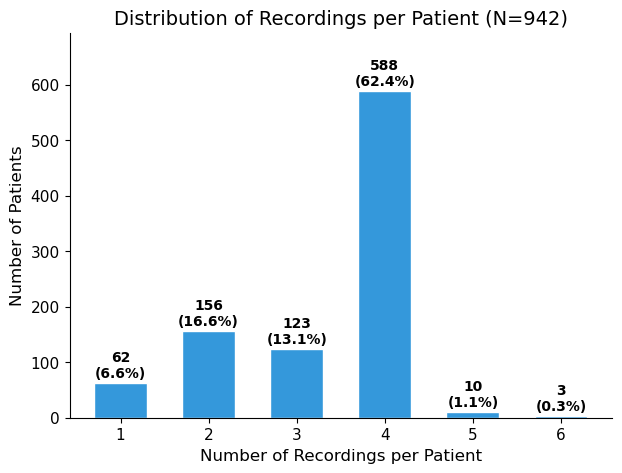

In [29]:
# Distribution of recordings per patient
rec_counts = patient_df["num_recordings"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    rec_counts.index.astype(str),
    rec_counts.values,
    color="#3498DB",
    edgecolor="white",
    width=0.6,
)

for bar, count in zip(bars, rec_counts.values):
    pct = count / len(patient_df) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{count}\n({pct:.1f}%)",
        ha="center", va="bottom", fontweight="bold", fontsize=10,
    )

ax.set_xlabel("Number of Recordings per Patient")
ax.set_ylabel("Number of Patients")
ax.set_title("Distribution of Recordings per Patient (N=942)")
ax.set_ylim(0, rec_counts.max() * 1.18)

fig.savefig("../figures/eda/v3_recordings_per_patient.png")
plt.show()

In [48]:
# Is there a bias? Do murmur patients tend to have more recordings?
cross = pd.crosstab(
    patient_df["num_recordings"],
    patient_df["murmur"],
    margins=True,
)
cross = cross[MURMUR_ORDER + ["All"]]
print("Recordings per patient × Murmur class:")
print(cross)

# Show prevalence rate per group
print("\nMurmur prevalence (%) by num_recordings:")
cross_pct = pd.crosstab(
    patient_df["num_recordings"],
    patient_df["murmur"],
    normalize="index",
) * 100
cross_pct = cross_pct[MURMUR_ORDER]
print(cross_pct.round(1).to_string())

Recordings per patient × Murmur class:
murmur          Present  Unknown  Absent  All
num_recordings                               
1                    10       16      36   62
2                    27       29     100  156
3                    22       10      91  123
4                   116       13     459  588
5                     2        0       8   10
6                     2        0       1    3
All                 179       68     695  942

Murmur prevalence (%) by num_recordings:
murmur          Present  Unknown  Absent
num_recordings                          
1                  16.1     25.8    58.1
2                  17.3     18.6    64.1
3                  17.9      8.1    74.0
4                  19.7      2.2    78.1
5                  20.0      0.0    80.0
6                  66.7      0.0    33.3


**Task 1.5 — Interpretation:**

**Phân bố:** 62.4% patients được ghi đủ 4 vị trí chuẩn (AV+PV+TV+MV). 
13 patients có 5–6 recordings — đây là trường hợp ghi lặp tại cùng vị trí 
(như patient 49748 đã thấy ở Task 1.1). 36.3% patients chỉ có 1–3 recordings, 
nghĩa là pipeline aggregation cần xử lý tốt trường hợp thiếu vị trí.

**Bias quan trọng — Unknown class tập trung ở patients có ít recordings:** 
Unknown prevalence giảm mạnh từ 25.8% (1 recording) xuống 2.2% (4 recordings). 
Đây là confound rõ ràng: patients có signal quality kém hoặc khó hợp tác 
(trẻ nhỏ, quấy khóc) có thể vừa bị ghi ít vị trí hơn, vừa khiến annotator 
không thể xác định murmur → gán Unknown. Điều này cũng phù hợp với 
Task 1.4: Unknown tập trung ở Neonate/Infant. Pipeline dùng confidence 
threshold C_ω̂ < 0.65 để gán Unknown — về cơ bản đang học lại pattern 
"signal quality thấp" này.

**Present class khá ổn định:** Murmur prevalence ~16–20% ổn định từ 1–5 recordings, 
cho thấy việc phát hiện murmur không bị bias bởi số lượng recordings.

## **Task 1.6 — Analyse recording durations distribution (→ V4)**

**Đang làm gì:** Trực quan hóa phân bố độ dài recordings, phân tách theo murmur class.

**Mục tiêu:** Hiểu biến thiên duration — ảnh hưởng đến RNN input length, padding/truncation, và số cardiac cycles có trong mỗi recording.

**Kết quả mong đợi:** 1 histogram overlay by murmur class, lưu ra `figures/eda/v4_recording_durations.png`.

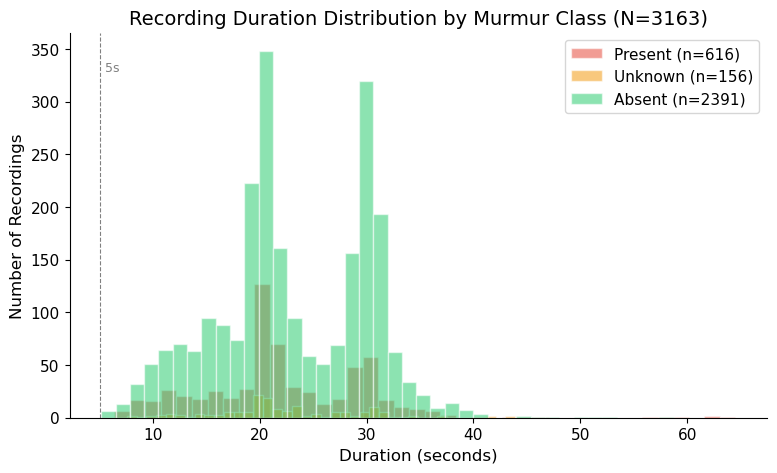

Duration stats by murmur class:
          count   mean   std   min    25%    50%    75%    max
murmur                                                        
Present   616.0  22.29  7.91  6.38  18.22  21.02  28.61  64.51
Unknown   156.0  22.40  6.99  7.55  19.17  21.07  27.21  43.89
Absent   2391.0  23.05  7.12  5.15  19.13  21.66  29.55  58.75


In [33]:
fig, ax = plt.subplots(figsize=(9, 5))

for cls in MURMUR_ORDER:
    data = recording_df[recording_df["murmur"] == cls]["duration_seconds"]
    ax.hist(
        data, bins=40, alpha=0.55,
        label=f"{cls} (n={len(data)})",
        color=MURMUR_COLORS[cls], edgecolor="white",
    )

ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("Number of Recordings")
ax.set_title("Recording Duration Distribution by Murmur Class (N=3163)")
ax.legend()

# Mark key thresholds
ax.axvline(x=5, color="gray", linestyle="--", linewidth=0.8)
ax.text(5.5, ax.get_ylim()[1] * 0.9, "5s", color="gray", fontsize=9)

fig.savefig("../figures/eda/v4_recording_durations.png")
plt.show()

# Summary stats by class
print("Duration stats by murmur class:")
print(
    recording_df.groupby("murmur")["duration_seconds"]
    .describe()
    .round(2)
    .loc[MURMUR_ORDER]
    .to_string()
)

**Task 1.6 — Interpretation:**

**Phân bố chung:** Recordings tập trung trong khoảng 15–32s (IQR), 
với 2 peak rõ ở ~20s và ~29s — có thể phản ánh protocol thu thập 
(clinician ghi khoảng 20s hoặc 30s tùy tình huống). Median ~21s 
ở cả 3 class cho thấy duration không bị bias bởi murmur status.

**Đủ dài cho phân tích:** Với nhịp tim trẻ em 80–120 bpm, 
recording 21s chứa ~28–42 cardiac cycles — dư sức cho RNN 
và HSMM phân tích pattern lặp lại. Recording ngắn nhất 5.15s 
vẫn chứa ~7–10 cycles.

**Outliers:** Vài recordings dài >40s, thậm chí 64.5s (Present class). 
Không gây vấn đề cho model vì RNN xử lý variable-length, 
nhưng recordings quá dài có thể chứa nhiều noise/movement artifacts.

**3 class gần như giống nhau về duration:** Mean ~22–23s, std ~7s ở cả 3 class. 
Đây là tin tốt — duration không phải confounding variable 
cho murmur classification.

## **Task 1.7 — Analyse murmur characteristics (→ V5, V6)**

**Đang làm gì:** Phân tích chi tiết đặc điểm murmur ở 179 patients có murmur Present — timing, grade, location, shape, pitch, quality.

**Mục tiêu:** Hiểu dataset chứa murmur loại nào. Ảnh hưởng trực tiếp đến model design — ví dụ nếu gần như toàn systolic thì 4 HSMM topologies (ω₁–ω₄) chỉ cần focus systolic timing.

**Kết quả mong đợi:** 2 plots (V5 location, V6 timing×grade) + text summary cho các đặc điểm khác.

In [34]:
murmur_df = patient_df[patient_df["murmur"] == "Present"].copy()
print(f"Murmur Present patients: {len(murmur_df)}")

Murmur Present patients: 179


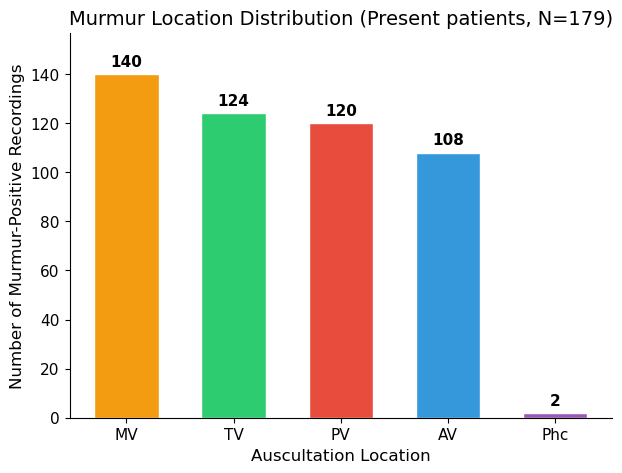


Murmur locations per patient: mean=2.8, median=3
murmur_locations
1    34
2    47
3    27
4    70
5     1


In [35]:
# Murmur locations can be multi-valued: "AV+MV+PV+TV"
# Split and count each location separately
all_locations = (
    murmur_df["murmur_locations"]
    .dropna()
    .str.split("+")
    .explode()
    .value_counts()
)

fig, ax = plt.subplots(figsize=(7, 5))

from src.visualisation.style import LOCATION_COLORS

bars = ax.bar(
    all_locations.index,
    all_locations.values,
    color=[LOCATION_COLORS.get(loc, "#999") for loc in all_locations.index],
    edgecolor="white",
    width=0.6,
)

for bar, count in zip(bars, all_locations.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(count),
        ha="center", va="bottom", fontweight="bold",
    )

ax.set_xlabel("Auscultation Location")
ax.set_ylabel("Number of Murmur-Positive Recordings")
ax.set_title("Murmur Location Distribution (Present patients, N=179)")
ax.set_ylim(0, all_locations.max() * 1.12)

fig.savefig("../figures/eda/v5_murmur_locations.png")
plt.show()

# How many locations per patient?
locs_per_patient = (
    murmur_df["murmur_locations"]
    .dropna()
    .str.split("+")
    .str.len()
)
print(f"\nMurmur locations per patient: mean={locs_per_patient.mean():.1f}, "
      f"median={locs_per_patient.median():.0f}")
print(locs_per_patient.value_counts().sort_index().to_string())

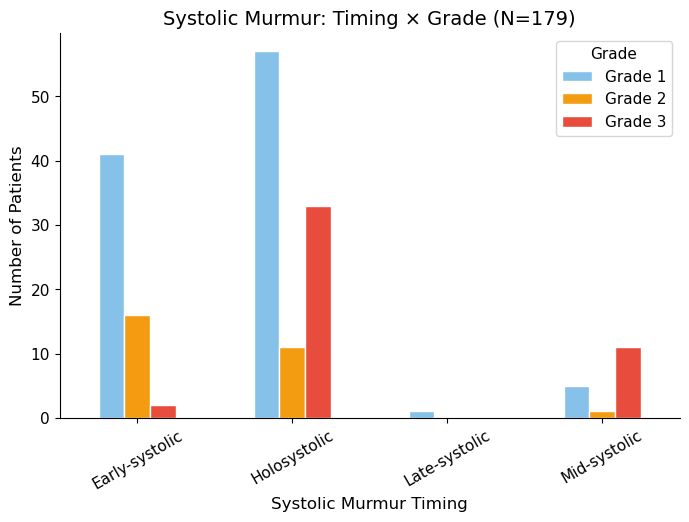

Timing × Grade cross-tabulation:
                        Grade 1  Grade 2  Grade 3
systolic_murmur_timing                           
Early-systolic               41       16        2
Holosystolic                 57       11       33
Late-systolic                 1        0        0
Mid-systolic                  5        1       11


In [36]:
# Cross-tabulation of timing vs grade
timing_grade = pd.crosstab(
    murmur_df["systolic_murmur_timing"],
    murmur_df["systolic_murmur_grading"],
)
# Rename grade columns for clarity
timing_grade.columns = [f"Grade {int(g)}" for g in timing_grade.columns]

fig, ax = plt.subplots(figsize=(8, 5))
timing_grade.plot(
    kind="bar", ax=ax,
    color=["#85C1E9", "#F39C12", "#E74C3C"],
    edgecolor="white",
)

ax.set_xlabel("Systolic Murmur Timing")
ax.set_ylabel("Number of Patients")
ax.set_title("Systolic Murmur: Timing × Grade (N=179)")
ax.legend(title="Grade")
ax.tick_params(axis="x", rotation=30)

fig.savefig("../figures/eda/v6_timing_grade_crosstab.png")
plt.show()

print("Timing × Grade cross-tabulation:")
print(timing_grade.to_string())

In [37]:
# Systolic vs Diastolic
systolic_n = murmur_df["systolic_murmur_timing"].notna().sum()
diastolic_n = murmur_df["diastolic_murmur_timing"].notna().sum()
print(f"Systolic murmurs: {systolic_n}")
print(f"Diastolic murmurs: {diastolic_n}")

# Shape, Pitch, Quality distributions
for col, label in [
    ("systolic_murmur_shape", "Shape"),
    ("systolic_murmur_pitch", "Pitch"),
    ("systolic_murmur_quality", "Quality"),
]:
    print(f"\nSystemic murmur {label}:")
    print(murmur_df[col].value_counts().to_string())

Systolic murmurs: 178
Diastolic murmurs: 5

Systemic murmur Shape:
systolic_murmur_shape
Plateau        111
Decrescendo     34
Diamond         31
Crescendo        2

Systemic murmur Pitch:
systolic_murmur_pitch
Low       87
Medium    49
High      42

Systemic murmur Quality:
systolic_murmur_quality
Harsh      96
Blowing    78
Musical     4


**Task 1.7 — Interpretation:**

**Locations (V5):** Murmur phân bố khá đều trên 4 vị trí chuẩn — MV (140) > TV (124) > PV (120) > AV (108). 
MV (mitral valve) dẫn đầu phù hợp lâm sàng vì mitral regurgitation là nguyên nhân murmur 
phổ biến nhất ở trẻ em. Trung bình mỗi patient có murmur ở 2.8 vị trí (median 3), 
và 70/179 patients (39%) nghe thấy murmur ở cả 4 vị trí — cho thấy murmur thường lan rộng, 
không chỉ khu trú. Đây là lý do pipeline dùng aggregation rule "nếu BẤT KỲ location nào 
phát hiện murmur → patient = Present."

**Timing × Grade (V6):** Gần như toàn bộ systolic (178/179), chỉ 5 diastolic — 
diastolic detection không khả thi với dataset này. Hai pattern chính:
- **Early-systolic Grade 1** (41 cases): murmur nhẹ, khó phát hiện — đây là nhóm 
  mà paper báo cáo 13 false negatives đều thuộc Grade 1
- **Holosystolic Grade 1 & 3** (57 + 33 cases): murmur kéo dài toàn systole, 
  Grade 3 dễ detect nhất vì biên độ lớn

Grade 1 chiếm 104/178 (58%) — quá nửa murmurs là loại nhẹ nhất, 
giải thích tại sao sensitivity cho Present class chỉ ~92.7% (paper) 
chứ không cao hơn.

**Đặc điểm khác:**
- Shape: Plateau (62%) chiếm đa số — murmur biên độ đều, dễ nhận diện hơn Decrescendo (19%)
- Pitch: Low (49%) phổ biến nhất — nằm trong dải tần mà log-spectrogram capture tốt
- Quality: Harsh (54%) và Blowing (44%) gần bằng nhau, Musical rất hiếm (4 cases)

**Implication cho model:** 4 HSMM topologies (ω₂ holosystolic, ω₃ early-systolic, 
ω₄ mid-systolic) phù hợp chính xác với 3 timing categories phổ biến nhất trong data. 
Late-systolic (1 case) quá hiếm để model học được.

## **Task 1.8 — Load and plot raw PCG waveforms (→ V7)**

**Đang làm gì:** Hiển thị raw PCG waveform — cho người đọc thấy dữ liệu thô trông như thế nào trước khi xử lý.

**Mục tiêu:** Chọn 3 recordings đại diện (normal, murmur rõ, noisy) và plot time-domain waveform. Các recordings này sẽ được dùng lại xuyên suốt Phase 2–4 để so sánh qua từng processing stage.

**Kết quả mong đợi:** 1 figure gồm 3 panels, lưu ra `figures/eda/v7_raw_waveforms.png`.

In [38]:
from scipy.io import wavfile

# === Chọn examples có chủ đích ===

# 1) Normal/clear: Absent patient, 4 recordings (good cooperation)
normal_candidates = patient_df[
    (patient_df["murmur"] == "Absent") & 
    (patient_df["num_recordings"] == 4)
].head(5)
print("Normal candidates:")
print(normal_candidates[["patient_id", "murmur", "age"]].to_string())

# 2) Murmur rõ: Present, Grade 3 (loud), Holosystolic (easiest to see)
murmur_candidates = patient_df[
    (patient_df["murmur"] == "Present") &
    (patient_df["systolic_murmur_grading"] == 3) &
    (patient_df["systolic_murmur_timing"] == "Holosystolic")
].head(5)
print("\nMurmur candidates (Grade 3, Holosystolic):")
print(murmur_candidates[["patient_id", "murmur", "systolic_murmur_grading", 
                          "systolic_murmur_timing", "most_audible_location"]].to_string())

# 3) Unknown: likely noisy/poor quality
unknown_candidates = patient_df[
    patient_df["murmur"] == "Unknown"
].head(5)
print("\nUnknown candidates:")
print(unknown_candidates[["patient_id", "murmur", "age", "num_recordings"]].to_string())

Normal candidates:
    patient_id  murmur    age
0         2530  Absent  Child
5        14998  Absent  Child
6        23625  Absent  Child
7        24160  Absent  Child
10       31737  Absent  Child

Murmur candidates (Grade 3, Holosystolic):
    patient_id   murmur  systolic_murmur_grading systolic_murmur_timing most_audible_location
1         9979  Present                      3.0           Holosystolic                    TV
21       44514  Present                      3.0           Holosystolic                    PV
33       49574  Present                      3.0           Holosystolic                    TV
43       49628  Present                      3.0           Holosystolic                    TV
68       49821  Present                      3.0           Holosystolic                    MV

Unknown candidates:
    patient_id   murmur     age  num_recordings
2         9983  Unknown   Child               4
9        29378  Unknown   Child               2
16       39456  Unknown   Ch

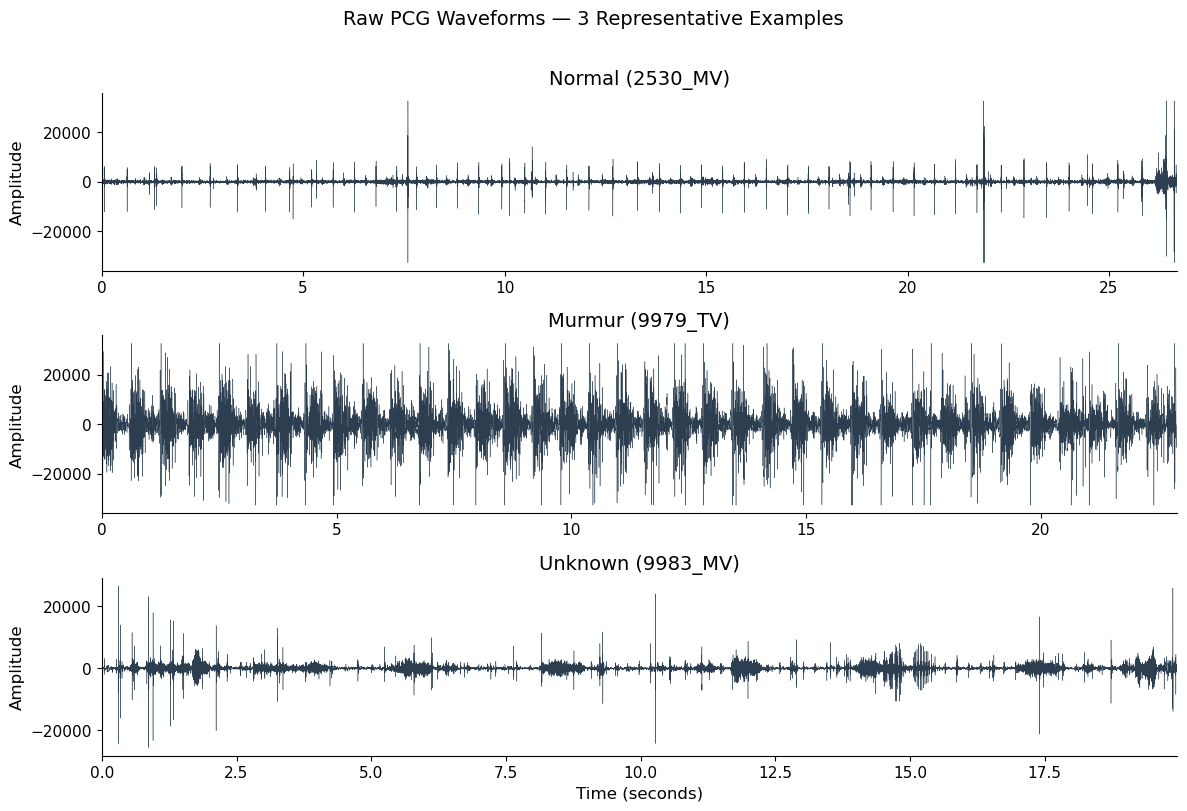

Normal (2530_MV): duration=26.7s, amplitude range=[-32768, 32767], RMS=1165.1
Murmur (9979_TV): duration=22.9s, amplitude range=[-32768, 32767], RMS=7038.2
Unknown (9983_MV): duration=20.0s, amplitude range=[-25521, 26511], RMS=1067.1


In [39]:
# === 3 example recordings — dùng lại xuyên suốt Phase 2–4 ===
EXAMPLES = {
    "Normal (2530_MV)":  "../data/raw/training_data/2530_MV.wav",
    "Murmur (9979_TV)":  "../data/raw/training_data/9979_TV.wav",
    "Unknown (9983_MV)": "../data/raw/training_data/9983_MV.wav",
}

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

for ax, (label, path) in zip(axes, EXAMPLES.items()):
    sr, audio = wavfile.read(path)
    time = np.arange(len(audio)) / sr
    
    ax.plot(time, audio, linewidth=0.3, color="#2C3E50")
    ax.set_ylabel("Amplitude")
    ax.set_title(label)
    ax.set_xlim(0, time[-1])

axes[-1].set_xlabel("Time (seconds)")
fig.suptitle("Raw PCG Waveforms — 3 Representative Examples", fontsize=14, y=1.01)
fig.tight_layout()

fig.savefig("../figures/eda/v7_raw_waveforms.png")
plt.show()

# Print basic stats
for label, path in EXAMPLES.items():
    sr, audio = wavfile.read(path)
    print(f"{label}: duration={len(audio)/sr:.1f}s, "
          f"amplitude range=[{audio.min()}, {audio.max()}], "
          f"RMS={np.sqrt(np.mean(audio.astype(float)**2)):.1f}")

**Task 1.8 — Interpretation:**

Ba waveforms cho thấy sự khác biệt rõ rệt bằng mắt thường:

**Normal (2530_MV):** Biên độ thấp (RMS=1165), tín hiệu "sạch" với các heart sounds 
(S1, S2) xuất hiện như spike nhỏ cách đều nhau. Khoảng lặng giữa các heart sounds 
rất rõ — đây là diastole yên tĩnh, đặc trưng của tim bình thường. 
Vài spike đột ngột (ví dụ ~7s, ~22s) là artifacts do di chuyển stethoscope.

**Murmur (9979_TV):** Biên độ cao hơn hẳn (RMS=7038, gấp 6× normal). Đặc biệt, 
không còn khoảng lặng rõ ràng giữa S1 và S2 — thay vào đó là dải năng lượng 
liên tục trong systole. Đây chính xác là dấu hiệu holosystolic murmur Grade 3: 
murmur lấp đầy toàn bộ khoảng systole với biên độ lớn. Pattern lặp đều đặn 
cho thấy chất lượng ghi tốt.

**Unknown (9983_MV):** Biên độ tương tự Normal (RMS=1067) nhưng pattern không đều — 
có đoạn gần như im lặng (~5–10s), sau đó biên độ tăng đột ngột (~12–16s). 
Sự không đều này khiến annotator không thể xác định murmur → gán Unknown. 
Có thể do trẻ cử động, stethoscope bị lệch, hoặc ghi âm bị gián đoạn.

**Observation quan trọng:** Amplitude range đạt max int16 (±32768) ở cả Normal 
và Murmur → có saturation/clipping. Đây là lý do pipeline cần amplitude 
normalisation trước khi trích xuất spectrogram (Phase 2).

**Example IDs ghi nhận:** 2530_MV (Normal), 9979_TV (Murmur), 9983_MV (Unknown) 
— sẽ dùng lại ở Phase 2 (preprocessing), Phase 3 (RNN output), Phase 4 (case studies).

## **Task 1.9 — Visualise segmentation annotations on waveforms (→ V8)**

**Đang làm gì:** Overlay ground-truth segmentation (S1, systole, S2, diastole) lên waveform của 3 recordings đã chọn.

**Mục tiêu:** Cho thấy labels mà RNN sẽ học predict trông như thế nào trên tín hiệu thật. Đây cũng là cách verify chất lượng annotations.

**Kết quả mong đợi:** 1 figure gồm 3 panels với các vùng màu biểu diễn S1, systole, S2 và diastole, lưu ra `figures/eda/v8_segmentation_overlay.png`.

In [42]:
# Reload style sau khi thêm state 0
import importlib
import src.visualisation.style as style
importlib.reload(style)
from src.visualisation.style import STATE_COLORS, STATE_LABELS

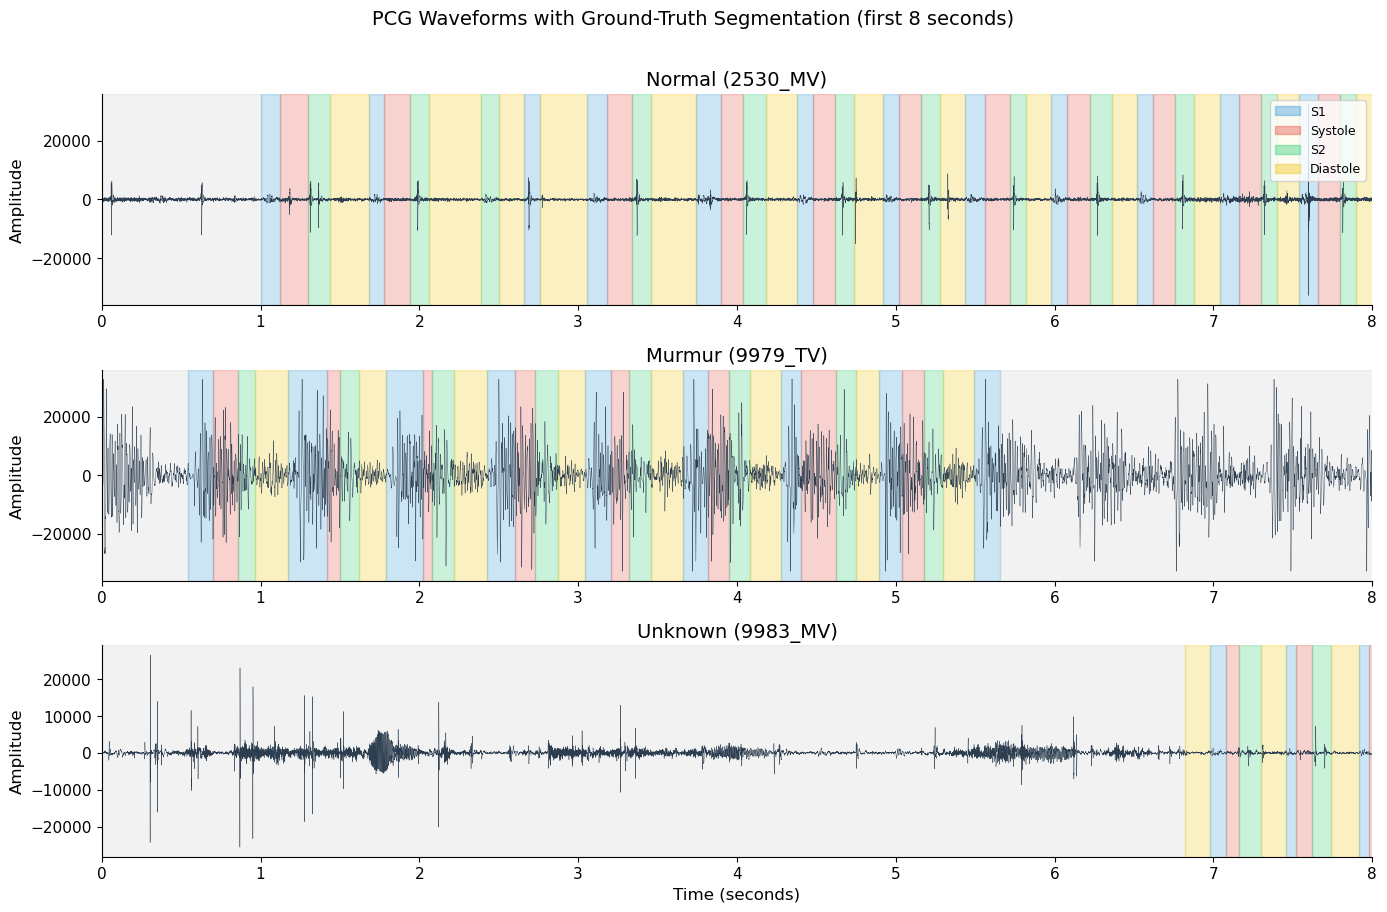

Normal (2530_MV): 175 segments, ~44 cardiac cycles
Murmur (9979_TV): 35 segments, ~9 cardiac cycles
Unknown (9983_MV): 43 segments, ~10 cardiac cycles


In [43]:
from src.visualisation.style import STATE_COLORS, STATE_LABELS

def load_segmentation(tsv_path):
    """Load .tsv segmentation file: columns = start, end, state (1-4)."""
    seg = pd.read_csv(tsv_path, sep="\t", header=None, 
                      names=["start", "end", "state"])
    return seg

# Same 3 examples as Task 1.8
EXAMPLES_TSV = {
    "Normal (2530_MV)": (
        "../data/raw/training_data/2530_MV.wav",
        "../data/raw/training_data/2530_MV.tsv",
    ),
    "Murmur (9979_TV)": (
        "../data/raw/training_data/9979_TV.wav",
        "../data/raw/training_data/9979_TV.tsv",
    ),
    "Unknown (9983_MV)": (
        "../data/raw/training_data/9983_MV.wav",
        "../data/raw/training_data/9983_MV.tsv",
    ),
}

fig, axes = plt.subplots(3, 1, figsize=(14, 9))

for ax, (label, (wav_path, tsv_path)) in zip(axes, EXAMPLES_TSV.items()):
    # Load audio
    sr, audio = wavfile.read(wav_path)
    time = np.arange(len(audio)) / sr
    
    # Plot waveform
    ax.plot(time, audio, linewidth=0.3, color="#2C3E50", zorder=2)
    
    # Load and overlay segmentation
    seg = load_segmentation(tsv_path)
    for _, row in seg.iterrows():
        ax.axvspan(
            row["start"], row["end"],
            alpha=0.25,
            color=STATE_COLORS[row["state"]],
            zorder=1,
        )
    
    ax.set_ylabel("Amplitude")
    ax.set_title(label)
    ax.set_xlim(0, min(time[-1], 8.0))  # Zoom to first 8s for readability

# Legend (only once)
from matplotlib.patches import Patch
legend_patches = [
    Patch(color=STATE_COLORS[s], alpha=0.4, label=STATE_LABELS[s])
    for s in [1, 2, 3, 4]
]
axes[0].legend(handles=legend_patches, loc="upper right", fontsize=9)

axes[-1].set_xlabel("Time (seconds)")
fig.suptitle("PCG Waveforms with Ground-Truth Segmentation (first 8 seconds)", 
             fontsize=14, y=1.01)
fig.tight_layout()

fig.savefig("../figures/eda/v8_segmentation_overlay.png")
plt.show()

# Print segment counts
for label, (_, tsv_path) in EXAMPLES_TSV.items():
    seg = load_segmentation(tsv_path)
    n_cycles = seg[seg["state"] == 1].shape[0]
    print(f"{label}: {len(seg)} segments, ~{n_cycles} cardiac cycles")

**Task 1.9 — Interpretation:**

**Normal (2530_MV):** Segmentation rất rõ ràng — S1 (blue) và S2 (green) khớp chính xác 
với các spike trong waveform, systole (red) và diastole (yellow) xen kẽ đều đặn. 
44 cardiac cycles trong 26.7s → nhịp tim ~99 bpm, nằm trong khoảng bình thường cho trẻ em. 
Đoạn đầu (~0–1s) là Unannotated (gray) — thời gian đặt stethoscope chưa ổn định.

**Murmur (9979_TV):** Khác biệt rõ rệt — trong vùng systole (red), biên độ tín hiệu 
KHÔNG giảm xuống như Normal mà duy trì cao liên tục. Đây chính là holosystolic murmur 
nhìn bằng mắt: tiếng murmur lấp đầy khoảng giữa S1 và S2. Chỉ 9 cardiac cycles 
trong 8 giây đầu → nhịp tim ~68 bpm. Đoạn Unannotated (gray) khá dài (~0–0.5s và ~5.5–7.5s) 
— annotator không xác định được heart sounds ở những đoạn này.

**Unknown (9983_MV):** Annotations rất thưa — phần lớn 8 giây đầu là Unannotated (gray), 
chỉ có vài segments nhỏ ở cuối (~7–8s). Tín hiệu có burst năng lượng không đều (~1.5s) 
xen lẫn đoạn gần im lặng. Annotator không thể xác định S1/S2 boundaries ổn định 
→ gán Unknown. Điều này xác nhận hypothesis từ Task 1.5 và 1.8: 
Unknown phản ánh signal quality, không phải clinical ambiguity.

**Insight cho model:** RNN sẽ học predict 5 states (4 cardiac + unannotated/murmur). 
Chất lượng annotations khác nhau rõ rệt giữa recordings — Normal có annotations dày đặc, 
Unknown gần như trống. Model cần robust với đầu vào có nhiều Unannotated segments.

## Task 1.10 — Signal quality proxies

**Approach:** Dùng segmentation annotations để tính 2 metrics per recording:
1. **Annotation coverage** = tỷ lệ recording được annotate (state 1–4) vs total duration. 
   Recordings chất lượng kém thường có nhiều đoạn Unannotated (state 0).
2. **SNR proxy** = tỷ lệ năng lượng trong S1+S2 (heart sounds) vs diastole (noise floor).
   SNR cao = heart sounds rõ ràng.
   
**Mục tiêu:** Kiểm tra hypothesis "Unknown = signal quality thấp" bằng số liệu, và xem signal quality phân bố thế nào giữa 3 class. Giúp giải thích tại sao pipeline dùng confidence threshold để gán Unknown.

In [44]:
from scipy.io import wavfile

def compute_quality_metrics(wav_path, tsv_path):
    """Compute signal quality proxies for one recording."""
    sr, audio = wavfile.read(wav_path)
    audio = audio.astype(np.float64)
    total_duration = len(audio) / sr
    
    seg = pd.read_csv(tsv_path, sep="\t", header=None,
                      names=["start", "end", "state"])
    
    # 1) Annotation coverage: fraction of recording with state 1-4
    annotated = seg[seg["state"] > 0]
    annotated_duration = (annotated["end"] - annotated["start"]).sum()
    coverage = annotated_duration / total_duration
    
    # 2) SNR proxy: energy in S1+S2 vs energy in diastole
    def get_energy(state_ids):
        """RMS energy for segments matching given states."""
        samples = []
        for _, row in seg[seg["state"].isin(state_ids)].iterrows():
            start_idx = int(row["start"] * sr)
            end_idx = int(row["end"] * sr)
            samples.append(audio[start_idx:end_idx])
        if not samples or all(len(s) == 0 for s in samples):
            return np.nan
        combined = np.concatenate(samples)
        return np.sqrt(np.mean(combined ** 2))
    
    rms_heart = get_energy([1, 3])       # S1 + S2
    rms_diastole = get_energy([4])       # Diastole = noise floor
    
    snr_proxy = np.nan
    if rms_diastole and rms_diastole > 0 and not np.isnan(rms_heart):
        snr_proxy = 10 * np.log10(rms_heart ** 2 / rms_diastole ** 2)
    
    return coverage, snr_proxy

# Compute for all recordings (takes a few minutes)
print("Computing quality metrics for 3163 recordings...")
coverages = []
snrs = []

for i, (_, row) in enumerate(recording_df.iterrows()):
    cov, snr = compute_quality_metrics(row["wav_path"], row["tsv_path"])
    coverages.append(cov)
    snrs.append(snr)
    if (i + 1) % 500 == 0:
        print(f"  {i + 1}/3163...")

recording_df["annotation_coverage"] = coverages
recording_df["snr_proxy_db"] = snrs
print("Done.")

Computing quality metrics for 3163 recordings...
  500/3163...
  1000/3163...
  1500/3163...
  2000/3163...
  2500/3163...
  3000/3163...
Done.


C:\Users\Admin\AppData\Local\Temp\ipykernel_16464\299018768.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


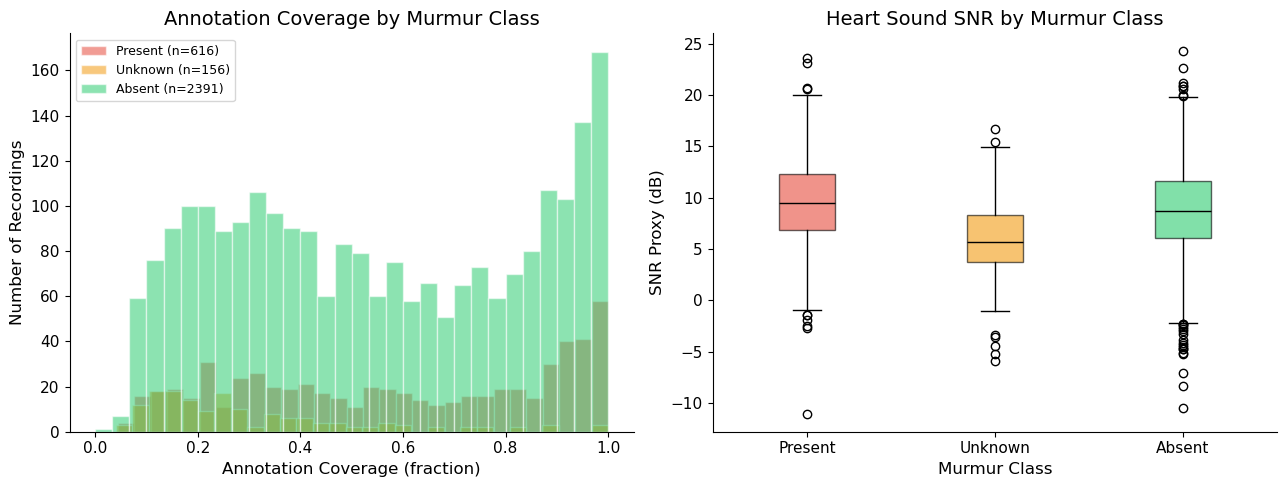

Annotation coverage by class:
          count   mean    std    min    25%    50%    75%  max
murmur                                                        
Present   616.0  0.589  0.296  0.044  0.319  0.596  0.889  1.0
Unknown   156.0  0.302  0.214  0.040  0.152  0.241  0.392  1.0
Absent   2391.0  0.549  0.289  0.000  0.294  0.520  0.833  1.0

SNR proxy (dB) by class:
          count  mean   std    min   25%   50%    75%    max
murmur                                                      
Present   616.0  9.59  4.14 -11.04  6.89  9.50  12.31  23.59
Unknown   156.0  5.97  3.97  -5.92  3.68  5.65   8.30  16.73
Absent   2390.0  8.78  4.19 -10.47  6.07  8.66  11.59  24.23


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Annotation coverage by class
for cls in MURMUR_ORDER:
    data = recording_df[recording_df["murmur"] == cls]["annotation_coverage"]
    axes[0].hist(
        data, bins=30, alpha=0.55,
        label=f"{cls} (n={len(data)})",
        color=MURMUR_COLORS[cls], edgecolor="white",
    )
axes[0].set_xlabel("Annotation Coverage (fraction)")
axes[0].set_ylabel("Number of Recordings")
axes[0].set_title("Annotation Coverage by Murmur Class")
axes[0].legend(fontsize=9)

# Right: SNR proxy by class (boxplot)
snr_data = [
    recording_df[recording_df["murmur"] == cls]["snr_proxy_db"].dropna()
    for cls in MURMUR_ORDER
]
bp = axes[1].boxplot(
    snr_data, labels=MURMUR_ORDER, patch_artist=True,
    medianprops=dict(color="black"),
)
for patch, cls in zip(bp["boxes"], MURMUR_ORDER):
    patch.set_facecolor(MURMUR_COLORS[cls])
    patch.set_alpha(0.6)
axes[1].set_xlabel("Murmur Class")
axes[1].set_ylabel("SNR Proxy (dB)")
axes[1].set_title("Heart Sound SNR by Murmur Class")

fig.tight_layout()
fig.savefig("../figures/eda/v_signal_quality.png")
plt.show()

# Summary stats
print("Annotation coverage by class:")
print(
    recording_df.groupby("murmur")["annotation_coverage"]
    .describe()
    .round(3)
    .loc[MURMUR_ORDER]
    .to_string()
)
print("\nSNR proxy (dB) by class:")
print(
    recording_df.groupby("murmur")["snr_proxy_db"]
    .describe()
    .round(2)
    .loc[MURMUR_ORDER]
    .to_string()
)

**Task 1.10 — Interpretation:**

**Annotation coverage — metric phân biệt rõ nhất:**
- **Unknown:** median chỉ 24.1%, mean 30.2% — nghĩa là ~75% recording KHÔNG được annotate. 
  Annotator không thể xác định S1/S2 boundaries → gần như toàn bộ recording là state 0.
- **Present:** median 59.6%, cao nhất — murmur rõ ràng giúp annotator dễ xác định heart sounds hơn.
- **Absent:** median 52.0%, phân bố rộng từ 0% đến 100%.

Annotation coverage thấp ở Unknown xác nhận hypothesis: **Unknown phản ánh signal quality, 
không phải clinical ambiguity**. Pipeline dùng confidence threshold C_ω̂ < 0.65 để gán Unknown 
về bản chất đang học lại pattern "annotations thưa = tín hiệu kém."

**SNR proxy:**
- **Present** có SNR cao nhất (median 9.5 dB) — heart sounds mạnh nhờ murmur tăng năng lượng 
  trong systole, khiến S1/S2 cũng nổi bật hơn so với diastole.
- **Unknown** có SNR thấp nhất (median 5.65 dB) — heart sounds yếu, khó phân biệt với noise.
- **Absent** ở giữa (median 8.66 dB).

Lưu ý: SNR cao ở Present không có nghĩa "tốt hơn" — nó phản ánh murmur 
tăng năng lượng tổng thể của tín hiệu. Metric hữu ích hơn để đánh giá 
signal quality thực sự là annotation coverage.

**Implication cho model:** Recordings có annotation coverage < 20% gần như 
không cung cấp training signal cho RNN (rất ít ground-truth labels). 
Đây là thách thức cần nhận thức khi training — model phải học từ recordings 
có chất lượng annotations rất khác nhau.

In [46]:
# Save recording_df with quality metrics added in Task 1.10
recording_df.to_csv("../data/metadata/recordings.csv", index=False)
print(f"Updated recordings.csv: {recording_df.shape} (added annotation_coverage, snr_proxy_db)")

Updated recordings.csv: (3163, 8) (added annotation_coverage, snr_proxy_db)


---
## EDA Key Findings Summary

### Dataset Overview
- **942 patients, 3163 recordings** across 5 auscultation locations (AV, PV, TV, MV, Phc)
- Paediatric population (76.5% Child), collected across 2 campaigns in Brazil (2014–2015)
- Median 4 recordings per patient; 62.4% have all 4 standard locations
- Recording duration: median ~21s (~28–42 cardiac cycles per recording)

### Class Imbalance — Central Challenge
- **Absent 73.8% / Present 19.0% / Unknown 7.2%**
- Justifies weighted accuracy metric (weights 5/3/1) and class-weighted loss in training
- Grade 1 (quiet) murmurs make up 58% of Present class — hardest to detect

### Demographic Insights
- Murmur prevalence stable (~19%) across age groups and sex — demographics are not strong predictors
- Pipeline correctly relies on PCG audio rather than metadata for murmur detection
- Missing data ~8–12% for age/height/weight — acceptable for clinical data

### Murmur Characteristics
- Near-exclusively systolic (178/179) — diastolic detection not feasible
- Murmurs heard at mean 2.8 locations per patient — often widespread, not localized
- Holosystolic (57%) and Early-systolic (33%) are dominant timing patterns
- 4 HSMM topologies (ω₁–ω₄) match the 3 major timing categories well

### Signal Quality — Key Insight
- **Unknown class = low signal quality**, not clinical ambiguity:
  - Annotation coverage: Unknown median 24% vs Present 60% vs Absent 52%
  - SNR proxy: Unknown median 5.7 dB vs Present 9.5 dB vs Absent 8.7 dB
  - Unknown concentrates in patients with fewer recordings (25.8% at 1 recording vs 2.2% at 4)
  - Unknown concentrates in younger patients (Neonates 16.7%, Infants 19.8%)
- Pipeline's confidence threshold (C_ω̂ < 0.65 → Unknown) effectively learns this pattern

### Observations for Model Design
1. Amplitude saturation (clipping at ±32768) present → normalisation needed (Phase 2)
2. Variable annotation density across recordings → RNN must handle sparse labels
3. Aggregation rule ("any location = Present") aligns with murmur being widespread
4. Grade 1 murmurs are the primary source of false negatives — improvement target

### Example Recordings for Cross-Phase Tracking
| Label | Patient | Location | Use |
|-------|---------|----------|-----|
| Normal | 2530 | MV | Baseline reference |
| Murmur | 9979 | TV | Grade 3 Holosystolic, clear murmur |
| Unknown | 9983 | MV | Low annotation coverage, signal quality issue |

In [47]:
# Quick notebook health check
print("=== DataFrames in memory ===")
print(f"patient_df: {patient_df.shape}")
print(f"recording_df: {recording_df.shape}")

print("\n=== Saved files ===")
import os
for f in ["../data/metadata/patients.csv", "../data/metadata/recordings.csv"]:
    size = os.path.getsize(f) / 1024
    print(f"  {f}: {size:.1f} KB")

print("\n=== Saved figures ===")
fig_dir = "../figures/eda/"
for f in sorted(os.listdir(fig_dir)):
    print(f"  {f}")

=== DataFrames in memory ===
patient_df: (942, 24)
recording_df: (3163, 8)

=== Saved files ===
  ../data/metadata/patients.csv: 84.4 KB
  ../data/metadata/recordings.csv: 430.6 KB

=== Saved figures ===
  v1_murmur_class_distribution.png
  v2a_age_by_murmur.png
  v2b_sex_by_murmur.png
  v2c_height_weight_by_murmur.png
  v3_recordings_per_patient.png
  v4_recording_durations.png
  v5_murmur_locations.png
  v6_timing_grade_crosstab.png
  v7_raw_waveforms.png
  v8_segmentation_overlay.png
  v_signal_quality.png
